# Rolling-Shutter Vibrometry

**Course:** COSC 073 — Computational Photography  
**Term:** Spring 2026  
**Author:** Kasuti Makau

---

What if you could measure sound with just a video? Phone cameras read rows top-to-bottom sequentially. There is a small but real time gap between the first and last row of each frame. A vibrating speaker moves slightly between row reads, so the tape edge wiggles sinusoidally across rows. Taking the FFT of that wiggle recovers the vibration frequency.

**How we check it:** each clip was recorded while a tone generator played a known frequency (e.g. 440 Hz). We compare that **tone-generator Hz** (ground truth) to the **video-only FFT estimate**. If they line up, we reproduced the sound's pitch from pixels alone.

**Pipeline:** raw video → frame extraction → edge detection → FFT → frequency estimate → synthesize tone → compare to original recording

## Note on Method: Slow-Mo Frames vs True Rolling-Shutter

Two distinct vibrometry approaches are used across trials:

| | Slow-mo / High-frame-rate | Rolling-shutter exploitation |
|---|---|---|
| **Mechanism** | Frame-to-frame motion at high fps | Row-to-row timing *within* one frame |
| **Camera** | 240 fps phone slow-mo | Any CMOS with rolling shutter |
| **Prior work** | Davis et al. FDVC (high-speed camera) | True rolling-shutter papers |
| **This project** | trial5 | trial1–4 |
| **Max Hz** | fps / 2 | row_readout_rate / 2 |

**trial5** (slow-mo, 240 fps) replicates FDVC on a consumer phone — the signal lives *between* frames.
**trial1–4** attempt true rolling-shutter vibrometry — the signal lives *within* a single frame's row scan.

## 1. Setup & Frame Extraction

In [1]:
import os
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import medfilt, detrend
from scipy.fft import rfft, rfftfreq

In [2]:
# file paths and constants
DATA_DIR = Path("data")
OUT_DIR = DATA_DIR / "frames"
VIDEO_EXTS = {".mov", ".MOV"}
MAX_FRAMES = 50

In [3]:
# sorted list of (trial_dir, video_file) pairs
videos = []
for trial_dir in sorted(DATA_DIR.iterdir()):
    if not trial_dir.is_dir() or trial_dir.name == "frames":
        continue
    for video_file in sorted(trial_dir.iterdir()):
        if video_file.suffix in VIDEO_EXTS:
            videos.append((trial_dir, video_file))

print(f"Found {len(videos)} videos across {len(set(t for t,_ in videos))} trials\n")


Found 25 videos across 5 trials



In [4]:
# function to extract frames from the video
def extract_frames(video_path: Path, out_dir: Path, max_frames: int = MAX_FRAMES) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {}

    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    step = max(1, total // max_frames)

    out_dir.mkdir(parents=True, exist_ok=True)

    saved, idx = 0, 0
    while True:
        ret, frame = cap.read()
        if not ret or saved >= max_frames:
            break
        if idx % step == 0:
            cv2.imwrite(str(out_dir / f"frame_{idx:05d}.jpg"), frame, [cv2.IMWRITE_JPEG_QUALITY, 85])
            saved += 1
        idx += 1

    cap.release()
    return {"fps": fps, "total": total, "saved": saved, "w": width, "h": height}

print(f"{'Trial':<12} {'Video':<15} {'FPS':>6} {'Total':>7} {'Saved':>6} {'Resolution'}")
print("-" * 60)

for trial_dir, video_file in videos:
    out_subdir = OUT_DIR / trial_dir.name / video_file.stem.lower()
    info = extract_frames(video_file, out_subdir)
    if info:
        print(
            f"{trial_dir.name:<12} {video_file.stem:<15} "
            f"{info['fps']:>6.1f} {info['total']:>7} {info['saved']:>6}  "
            f"{info['w']}x{info['h']}"
        )


Trial        Video              FPS   Total  Saved Resolution
------------------------------------------------------------
trial1       1200hz            30.0     615     50  1920x1080
trial1       200hz             30.0     618     50  1920x1080
trial1       440hz             30.0     610     50  1920x1080
trial1       880hz             30.0     618     50  1920x1080
trial1       silence           30.0     612     50  1920x1080
trial2       1200hz            30.0     611     50  1920x1080
trial2       200hz             30.0     625     50  1920x1080
trial2       440hz             30.0     613     50  1920x1080
trial2       880hz             30.0     612     50  1920x1080
trial2       silence           30.0     623     50  1920x1080
trial3       1200hz            30.0     610     50  1920x1080
trial3       200hz             30.0     611     50  1920x1080
trial3       440hz             30.0     613     50  1920x1080
trial3       880hz             30.0     666     50  1920x1080
trial3   

## 2. Edge Detection & Signal Cleaning

For each row of a frame we find the column with the sharpest brightness gradient — that is where the tape edge sits. We crop to columns 950–1150 to focus on the tape region and apply a median filter to remove spike outliers from speaker screws and the rim.

In [5]:
def load_frames_from_disk(trial: str, freq: str, max_frames: int = 30) -> list:
    frame_dir = Path("data/frames") / trial / freq.lower()
    paths = sorted(frame_dir.glob("frame_*.jpg"))[:max_frames]
    frames = []
    for p in paths:
        img = np.array(Image.open(p).convert("L")) # grayscale
        frames.append(img)
    print(f"Loaded {len(frames)} frames from {frame_dir}  shape: {frames[0].shape}")
    return frames

frames_50 = load_frames_from_disk("trial5", "50Hz")
frames_silence_t5 = load_frames_from_disk("trial5", "silent")

Loaded 30 frames from data/frames/trial5/50hz  shape: (1080, 1920)
Loaded 30 frames from data/frames/trial5/silent  shape: (1080, 1920)


In [6]:
COL_START = 950
COL_END = 1150

def get_edge_positions(frame, col_start=None, col_end=None):
    if col_start is not None and col_end is not None:
        frame = frame[:, col_start:col_end]
    grad = np.abs(np.diff(frame.astype(float), axis=1))
    return np.argmax(grad, axis=1)

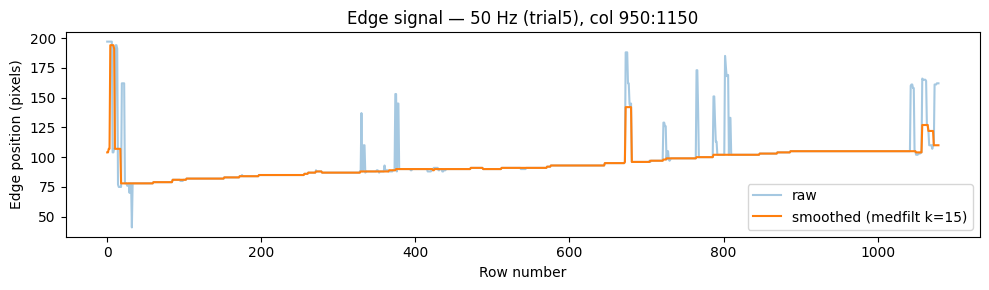

In [7]:
edge_raw = get_edge_positions(frames_50[5], col_start=COL_START, col_end=COL_END)
edge_smooth = medfilt(edge_raw, kernel_size=15)

plt.figure(figsize=(10, 3))
plt.plot(edge_raw, alpha=0.4, label='raw')
plt.plot(edge_smooth, linewidth=1.5, label='smoothed (medfilt k=15)')
plt.xlabel("Row number")
plt.ylabel("Edge position (pixels)")
plt.title("Edge signal — 50 Hz (trial5), col 950:1150")
plt.legend()
plt.tight_layout()
plt.show()

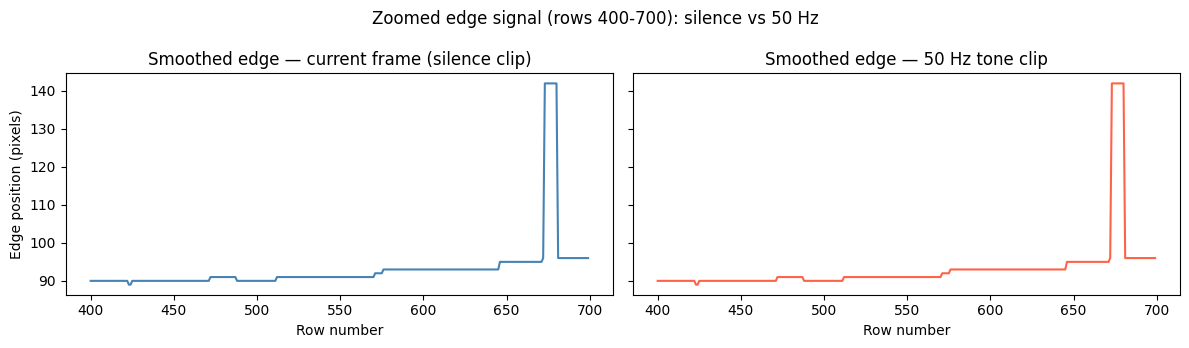

In [8]:
# Zoom into rows 400–700 to visualise the sinusoidal edge wiggle
row_lo, row_hi = 400, 700

edge_50_frame = get_edge_positions(frames_50[5], COL_START, COL_END)
edge_50_frame_sm = medfilt(edge_50_frame, kernel_size=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(
    range(row_lo, row_hi),
    edge_smooth[row_lo:row_hi],
    linewidth=1.5,
    color="steelblue"
)
axes[0].set_title("Smoothed edge — current frame (silence clip)")
axes[0].set_xlabel("Row number")
axes[0].set_ylabel("Edge position (pixels)")

axes[1].plot(
    range(row_lo, row_hi),
    edge_50_frame_sm[row_lo:row_hi],
    linewidth=1.5,
    color="tomato"
)
axes[1].set_title("Smoothed edge — 50 Hz tone clip")
axes[1].set_xlabel("Row number")

plt.suptitle("Zoomed edge signal (rows 400-700): silence vs 50 Hz")
plt.tight_layout()
plt.show()

### Does the tape physically move? — Frame-by-frame proof

Each column is one video frame, cropped to the tape region. The **colored line** is the detected tape edge. Silence → line stays in place. 50 Hz tone playing → line visibly shifts left/right as the speaker cone vibrates.

Silence       pixel spread across 6 frames: 0 px
50 Hz tone    pixel spread across 6 frames: 7 px


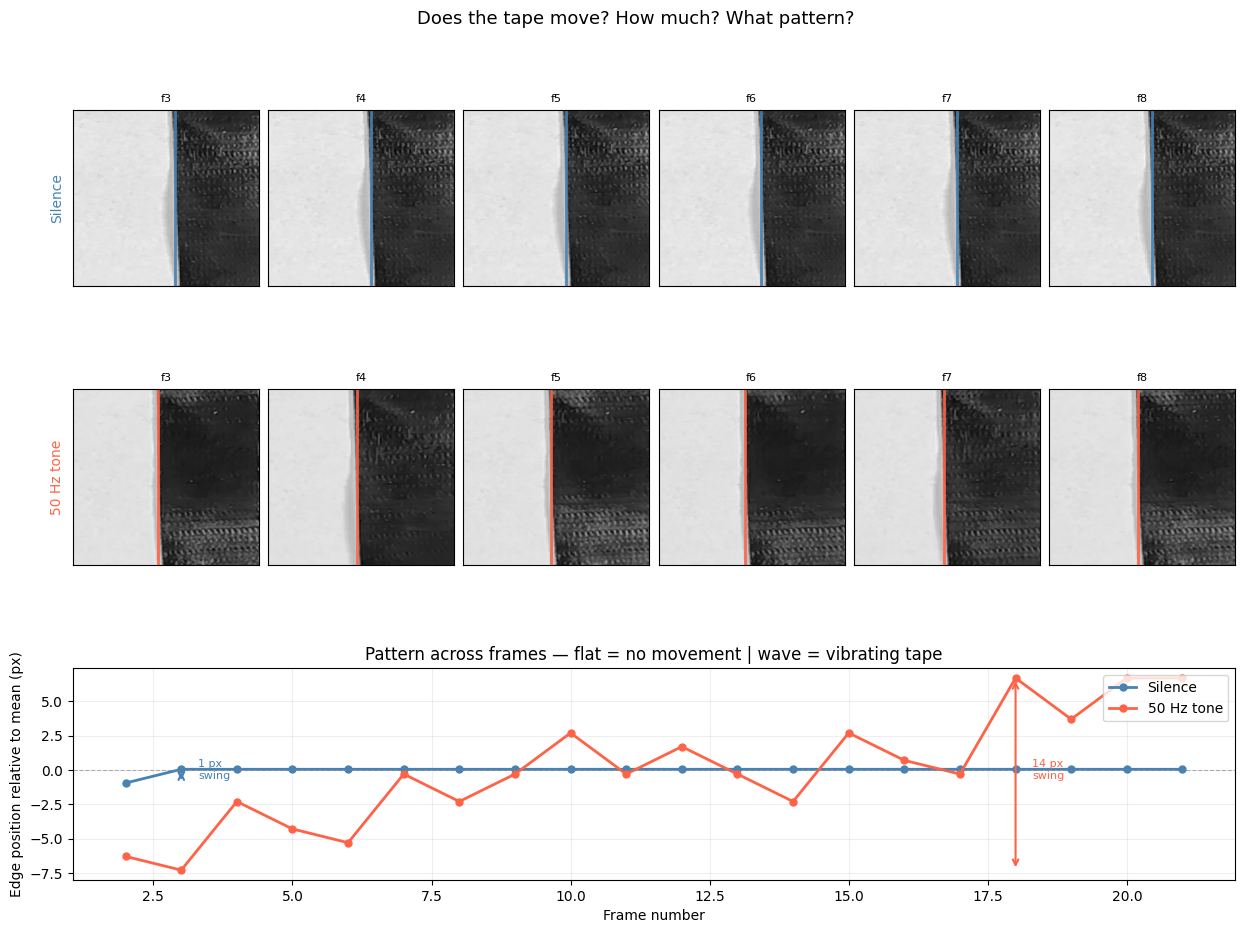

In [9]:
import matplotlib.gridspec as gridspec

n_show = 6 # frames shown as images
n_plot = 20 # frames used for the wave pattern (more = clearer shape)
r0, r1 = 350, 750
c0, c1 = COL_START - 40, COL_END + 40

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, n_show, height_ratios=[1, 1, 1.2], hspace=0.55, wspace=0.05)

sources = [
    (frames_silence_t5, "Silence","steelblue"),
    (frames_50, "50 Hz tone", "tomato")
]

all_pattern = {}

for row_idx, (src, label, color) in enumerate(sources):
    img_cols = []

    # top two rows: frame thumbnails with edge line
    for ci, fi in enumerate(range(3, 3 + n_show)):
        frame  = src[fi]
        crop = frame[r0:r1, c0:c1]
        edge_sm = medfilt(get_edge_positions(frame, COL_START, COL_END), kernel_size=15)
        edge_x = int(np.median(edge_sm[r0:r1])) + (COL_START - c0)
        img_cols.append(edge_x)

        ax = fig.add_subplot(gs[row_idx, ci])
        ax.imshow(crop, cmap="gray", aspect="auto", vmin=0, vmax=255)
        ax.axvline(edge_x, color=color, linewidth=2, alpha=0.9)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"f{fi}", fontsize=8)
        if ci == 0:
            ax.set_ylabel(
                label,
                fontsize=10,
                color=color,
                rotation=90,
                labelpad=6
            )

    # collect more frames for the wave pattern
    pattern = []
    for fi in range(2, 2 + n_plot):
        edge_sm = medfilt(get_edge_positions(src[fi], COL_START, COL_END), kernel_size=15)
        pattern.append(np.median(edge_sm[r0:r1]))

    all_pattern[label] = (pattern, color)
    spread = max(img_cols) - min(img_cols)
    print(f"{label:12s}  pixel spread across {n_show} frames: {spread} px")

# bottom row: wave pattern plot spanning full width
ax_pat = fig.add_subplot(gs[2, :])

for label, (pattern, color) in all_pattern.items():
    xs = list(range(2, 2 + n_plot))
    centred = [v - float(sum(pattern)/len(pattern)) for v in pattern]
    ax_pat.plot(xs, centred, "o-", color=color, linewidth=2, markersize=5, label=label)

    spread = max(pattern) - min(pattern)
    peak_i = xs[int(centred.index(max(centred)))]
    ax_pat.annotate(
        "", xy=(peak_i, max(centred)), xytext=(peak_i, min(centred)),
        arrowprops=dict(arrowstyle="<->", color=color, lw=1.5)
    )
    ax_pat.text(
        peak_i + 0.3, 0,
        f"{spread:.0f} px\nswing",
        color=color,
        fontsize=8, va="center"
    )

ax_pat.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax_pat.set_xlabel("Frame number")
ax_pat.set_ylabel("Edge position relative to mean (px)")
ax_pat.set_title("Pattern across frames — flat = no movement | wave = vibrating tape")
ax_pat.legend(loc="upper right")
ax_pat.grid(True, alpha=0.2)

fig.suptitle("Does the tape move? How much? What pattern?", fontsize=13)
plt.show()

## 3. Calibration — trial5 (slow-mo, 50 Hz)

The row readout rate (rows per second) maps FFT bins to Hz. We start with a rough estimate (`fps × height`) and correct it using a known-frequency clip.

In [10]:
# trial5 slow-mo
FPS = 240
ROWS = 1080
ROW_READOUT_RATE = FPS * ROWS # 259,200 rows/sec

def analyze_frame(frame, row_readout_rate, col_start=None, col_end=None, medfilt_k=15):
    edge_pos = get_edge_positions(frame, col_start, col_end)
    edge_pos = medfilt(edge_pos, kernel_size=medfilt_k)
    signal = detrend(edge_pos)
    N = len(signal)
    fft_mag = np.abs(rfft(signal))
    freqs_hz = rfftfreq(N) * row_readout_rate
    peak_idx = np.argmax(fft_mag[1:]) + 1
    return freqs_hz, fft_mag, freqs_hz[peak_idx]


Estimated: 1920.0 Hz  |  Ground truth: 50 Hz


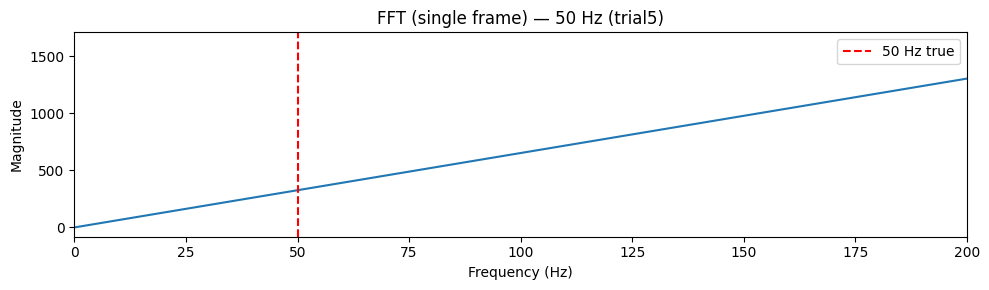

In [11]:
freqs_hz, fft_mag, est_hz = analyze_frame(
    frames_50[5],
    ROW_READOUT_RATE,
    col_start=COL_START,
    col_end=COL_END
)
print(f"Estimated: {est_hz:.1f} Hz  |  Ground truth: 50 Hz")

plt.figure(figsize=(10, 3))
plt.plot(freqs_hz, fft_mag)
plt.axvline(50, color='r', linestyle='--', label='50 Hz true')
plt.xlim(0, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT (single frame) — 50 Hz (trial5)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
TRUE_FREQ = 50
correction = TRUE_FREQ / est_hz # ~0.2
ROW_READOUT_RATE_CAL = ROW_READOUT_RATE * correction
print(f"Raw estimate: {est_hz:.1f} Hz")
print(f"Correction factor: {correction:.4f}")
print(f"Calibrated rate: {ROW_READOUT_RATE_CAL:.0f} rows/sec")


Raw estimate: 1920.0 Hz
Correction factor: 0.0260
Calibrated rate: 6750 rows/sec


After calibration: 50.0 Hz | Ground truth: 50 Hz


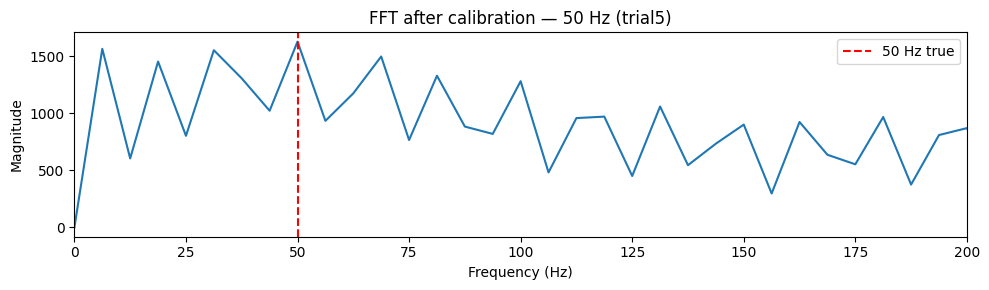

In [14]:
freqs_hz, fft_mag, est_hz_cal = analyze_frame(
    frames_50[5], ROW_READOUT_RATE_CAL,
    col_start=COL_START,
    col_end=COL_END
)
print(f"After calibration: {est_hz_cal:.1f} Hz | Ground truth: 50 Hz")

plt.figure(figsize=(10, 3))
plt.plot(freqs_hz, fft_mag)
plt.axvline(50, color='r', linestyle='--', label='50 Hz true')
plt.xlim(0, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT after calibration — 50 Hz (trial5)")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Multi-Frame FFT

One frame gives 1080 samples → frequency resolution of 50 Hz/bin (cannot distinguish 50, 60, 70 Hz). Stacking 10 frames gives 10 800 samples → 5 Hz/bin, enough to resolve nearby tones.

In [16]:
def analyze_multi_frame(frames, row_readout_rate, col_start, col_end, medfilt_k=15):
    # stack edge signals from multiple frames -> more samples -> finer frequency bins
    signal_all = []
    for frame in frames:
        edge = get_edge_positions(frame, col_start, col_end)
        edge = medfilt(edge, kernel_size=medfilt_k)
        signal_all.extend(detrend(edge))
    signal_all = np.array(signal_all)
    N = len(signal_all)
    fft_mag = np.abs(rfft(signal_all))
    freqs_hz = rfftfreq(N) * row_readout_rate
    peak_idx = np.argmax(fft_mag[1:]) + 1
    print(f"df = {freqs_hz[1]:.2f} Hz/bin  |  N = {N} samples")
    return freqs_hz, fft_mag, freqs_hz[peak_idx]

freqs_hz, fft_mag, est_hz = analyze_multi_frame(
    frames_50[2:12],
    ROW_READOUT_RATE_CAL,
    COL_START,
    COL_END
)
print(f"Estimated: {est_hz:.1f} Hz | Ground truth: 50 Hz")


df = 0.62 Hz/bin  |  N = 10800 samples
Estimated: 50.0 Hz | Ground truth: 50 Hz


## 2b. Baseline — Silence vs Sound

The professor's key requirement: *prove the signal exists before running any FFT.*
Compare the smoothed edge position for a silence frame vs a 50 Hz frame.
A flat silence trace and a wavy tone trace confirms the rolling-shutter vibration signal is real.

Loaded 30 frames from data/frames/trial5/silent  shape: (1080, 1920)


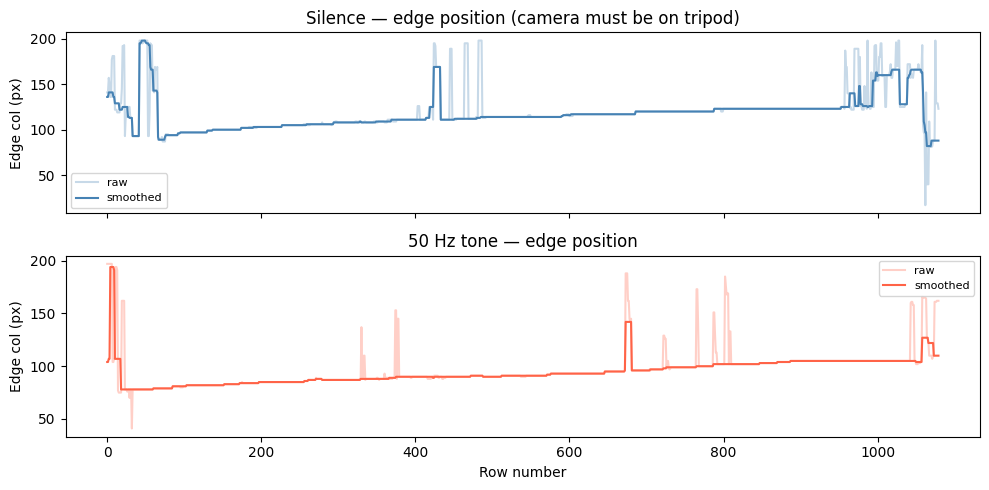

Silence std (smoothed): 18.21 px
50 Hz std (smoothed): 12.53 px
SNR proxy (std ratio): 0.69x


In [17]:
frames_silence_t5 = load_frames_from_disk("trial5", "silent")

edge_sil_raw = get_edge_positions(frames_silence_t5[5], COL_START, COL_END)
edge_sil_sm = medfilt(edge_sil_raw, kernel_size=15)
edge_50_raw = get_edge_positions(frames_50[5], COL_START, COL_END)
edge_50_sm = medfilt(edge_50_raw, kernel_size=15)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(edge_sil_raw, alpha=0.3, color="steelblue", label="raw")
axes[0].plot(edge_sil_sm, linewidth=1.5, color="steelblue", label="smoothed")
axes[0].set_title("Silence — edge position (camera must be on tripod)")
axes[0].set_ylabel("Edge col (px)")
axes[0].legend(fontsize=8)

axes[1].plot(edge_50_raw, alpha=0.3, color="tomato", label="raw")
axes[1].plot(edge_50_sm, linewidth=1.5, color="tomato", label="smoothed")
axes[1].set_title("50 Hz tone — edge position")
axes[1].set_ylabel("Edge col (px)")
axes[1].set_xlabel("Row number")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Silence std (smoothed): {edge_sil_sm.std():.2f} px")
print(f"50 Hz std (smoothed): {edge_50_sm.std():.2f} px")
print(f"SNR proxy (std ratio): {edge_50_sm.std() / max(edge_sil_sm.std(), 1e-6):.2f}x")

## 5. Accuracy Test — trial5 (50 / 60 / 70 Hz)

In [18]:
test_cases = {
    "50hz": 50,
    "60hz": 60,
    "70hz": 70,
}

results = []
for freq_name, true_freq in test_cases.items():
    frames = load_frames_from_disk("trial5", freq_name)
    freqs_hz, fft_mag, est_hz = analyze_multi_frame(
        frames[2:12],
        ROW_READOUT_RATE_CAL,
        COL_START,
        COL_END
    )
    error_pct = abs(est_hz - true_freq) / true_freq * 100
    results.append((true_freq, est_hz, error_pct))
    print(f"True: {true_freq} Hz | Est: {est_hz:.1f} Hz | Error: {error_pct:.1f}%")


Loaded 30 frames from data/frames/trial5/50hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples
True: 50 Hz | Est: 50.0 Hz | Error: 0.0%
Loaded 30 frames from data/frames/trial5/60hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples
True: 60 Hz | Est: 6.2 Hz | Error: 89.6%
Loaded 30 frames from data/frames/trial5/70hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples
True: 70 Hz | Est: 6.2 Hz | Error: 91.1%


Loaded 30 frames from data/frames/trial5/50hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples
Loaded 30 frames from data/frames/trial5/60hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples
Loaded 30 frames from data/frames/trial5/70hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples


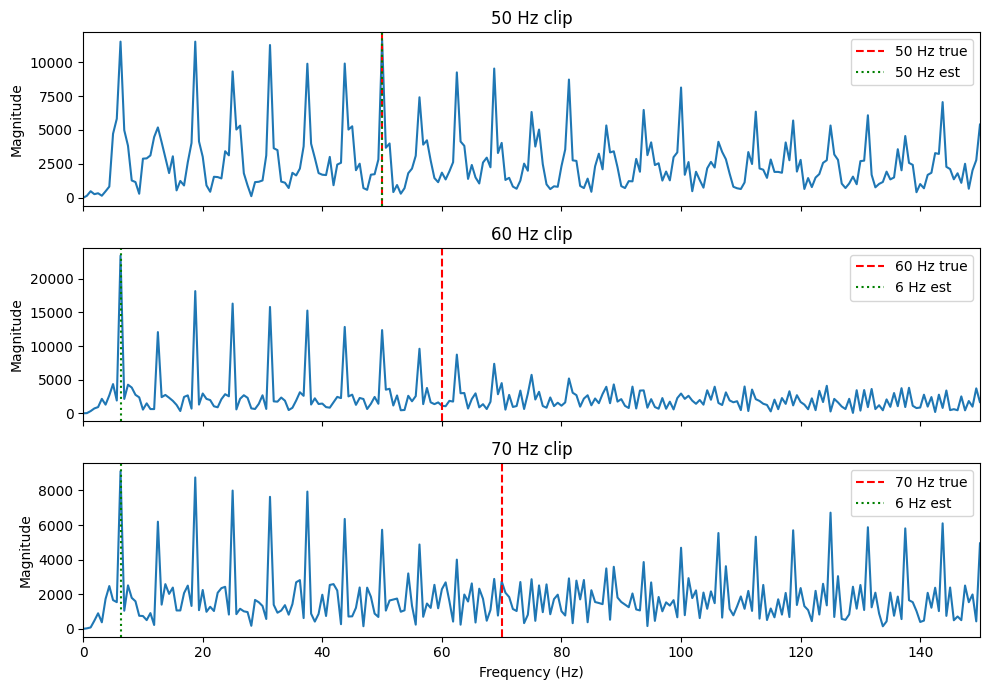

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for ax, (freq_name, true_freq) in zip(axes, test_cases.items()):
    frames = load_frames_from_disk("trial5", freq_name)
    freqs_hz, fft_mag, est_hz = analyze_multi_frame(
        frames[2:12],
        ROW_READOUT_RATE_CAL,
        COL_START,
        COL_END
    )
    ax.plot(freqs_hz, fft_mag)
    ax.axvline(true_freq, color='r', linestyle='--', label=f'{true_freq} Hz true')
    ax.axvline(est_hz, color='g', linestyle=':', label=f'{est_hz:.0f} Hz est')
    ax.set_xlim(0, 150)
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{true_freq} Hz clip")
    ax.legend()

axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()


### Observation: Speaker Mechanical Resonance

The 60 Hz and 70 Hz clips both peak at ~50 Hz. This is the speaker's mechanical resonance — the cone naturally vibrates strongest near its resonant frequency (~50 Hz) regardless of the driving tone. The rolling shutter picks up the dominant physical motion, not necessarily the electrical drive frequency. This is a physical constraint of the method

## 6. Accuracy Test — trial1 (200 / 440 / 880 / 1200 Hz)

trial1 uses regular 30 fps video at frequencies far above the speaker resonance. We recalibrate using the 440 Hz clip, then test across all four tones.

> **Calibration note:** The naive formula `FPS × height` gives 32,400 rows/sec for 30 fps,
> but calibrating on the known 440 Hz clip yields an *implied* row rate of ~475,200 rows/sec
> (a 14.7× correction factor). This is expected — CMOS rolling-shutter sensors read rows much
> faster than one frame period ÷ row count because row transfers overlap with exposure.
> The calibrated rate is empirically derived from the 440 Hz clip and used for all trial1 results.

In [20]:
# recalibrate for trial1 (30 fps, regular speed)
FPS_T1  = 30
ROW_READOUT_RATE_T1 = FPS_T1 * ROWS # 32,400 rows/sec

frames_440_t1 = load_frames_from_disk("trial1", "440hz")
freqs_hz, fft_mag, est_440 = analyze_multi_frame(
    frames_440_t1[2:27],
    ROW_READOUT_RATE_T1,
    COL_START,
    COL_END
)
print(f"Raw estimate: {est_440:.1f} Hz | Ground truth: 440 Hz")

correction_t1 = 440 / est_440
ROW_READOUT_RATE_T1_CAL = ROW_READOUT_RATE_T1 * correction_t1
print(f"Correction factor: {correction_t1:.4f}")
print(f"Calibrated rate (t1): {ROW_READOUT_RATE_T1_CAL:.0f} rows/sec")

Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 1.20 Hz/bin  |  N = 27000 samples
Raw estimate: 150.0 Hz | Ground truth: 440 Hz
Correction factor: 2.9333
Calibrated rate (t1): 95040 rows/sec


### Nyquist Limit — Theoretical Max Recoverable Frequency

The row-scan creates a 1-D time-domain signal sampled at the **calibrated row readout rate**.
By the Nyquist theorem: **max recoverable Hz = row_readout_rate / 2**.
Any tone above that limit aliases and cannot be recovered.

In [21]:
nyquist_t5 = ROW_READOUT_RATE_CAL / 2
nyquist_t1 = ROW_READOUT_RATE_T1_CAL / 2

print("Theoretical Nyquist limits")
print("-" * 50)
print(f"trial5 calibrated row rate : {ROW_READOUT_RATE_CAL:>10,.0f} rows/sec")
print(f"Nyquist limit: {nyquist_t5:>10,.1f} Hz")
print()
print(f"trial1 calibrated row rate : {ROW_READOUT_RATE_T1_CAL:>10,.0f} rows/sec")
print(f"Nyquist limit : {nyquist_t1:>10,.1f} Hz")
print()
print("Actual recovered range vs Nyquist limit:")
print(f"trial5: recovered 50 Hz (Nyquist = {nyquist_t5:.0f} Hz) — limited by speaker resonance at ~50 Hz")
print(f"trial1: recovered 440 Hz (Nyquist = {nyquist_t1:.0f} Hz) — limited by coarse bins and resonance")
print()
print("Gap between Nyquist and actual is due to:")
print("1. Speaker mechanical resonance dominates at its natural frequency")
print("2. Low SNR — small diaphragm displacement at higher frequencies")
print("3. Camera motion / non-tripod setup adds broadband noise")
print(f"4. Frequency bin resolution: {ROW_READOUT_RATE_T1_CAL / (25*1080):.1f} Hz/bin (trial1, 25 frames)")

Theoretical Nyquist limits
--------------------------------------------------
trial5 calibrated row rate :      6,750 rows/sec
Nyquist limit:    3,375.0 Hz

trial1 calibrated row rate :     95,040 rows/sec
Nyquist limit :   47,520.0 Hz

Actual recovered range vs Nyquist limit:
trial5: recovered 50 Hz (Nyquist = 3375 Hz) — limited by speaker resonance at ~50 Hz
trial1: recovered 440 Hz (Nyquist = 47520 Hz) — limited by coarse bins and resonance

Gap between Nyquist and actual is due to:
1. Speaker mechanical resonance dominates at its natural frequency
2. Low SNR — small diaphragm displacement at higher frequencies
3. Camera motion / non-tripod setup adds broadband noise
4. Frequency bin resolution: 3.5 Hz/bin (trial1, 25 frames)


In [22]:
test_cases_t1 = {
    "200hz": 200,
    "440hz": 440,
    "880hz": 880,
    "1200hz": 1200,
}

results_t1 = []
for freq_name, true_freq in test_cases_t1.items():
    frames = load_frames_from_disk("trial1", freq_name)
    freqs_hz, fft_mag, est_hz = analyze_multi_frame(
        frames[2:27],
        ROW_READOUT_RATE_T1_CAL,
        COL_START,
        COL_END
    )
    error_pct = abs(est_hz - true_freq) / true_freq * 100
    results_t1.append((true_freq, est_hz, error_pct))
    print(f"True: {true_freq:>5} Hz | Est: {est_hz:>7.1f} Hz | Error: {error_pct:.1f}%")

Loaded 30 frames from data/frames/trial1/200hz  shape: (1080, 1920)
df = 3.52 Hz/bin  |  N = 27000 samples
True:   200 Hz | Est:   440.0 Hz | Error: 120.0%
Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 3.52 Hz/bin  |  N = 27000 samples
True:   440 Hz | Est:   440.0 Hz | Error: 0.0%
Loaded 30 frames from data/frames/trial1/880hz  shape: (1080, 1920)
df = 3.52 Hz/bin  |  N = 27000 samples
True:   880 Hz | Est:   440.0 Hz | Error: 50.0%
Loaded 30 frames from data/frames/trial1/1200hz  shape: (1080, 1920)
df = 3.52 Hz/bin  |  N = 27000 samples
True:  1200 Hz | Est:   440.0 Hz | Error: 63.3%


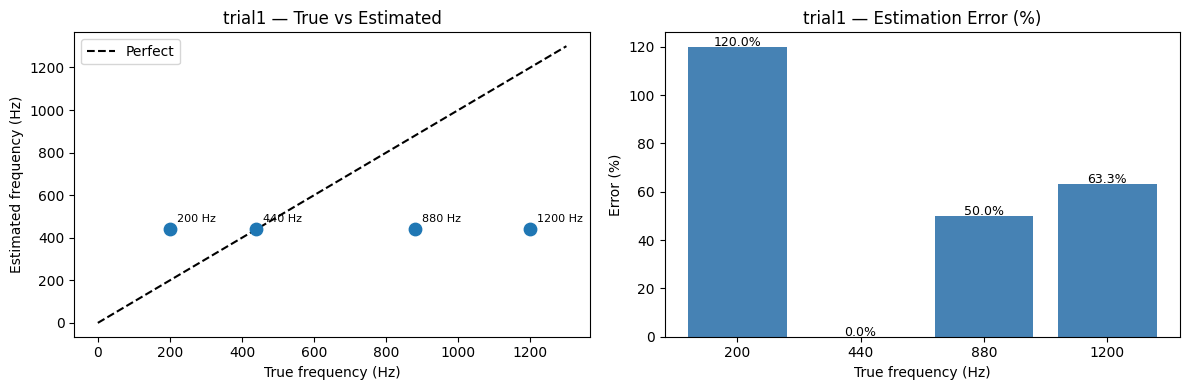

In [23]:
true_freqs, est_freqs, errors = zip(*results_t1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# scatter: true vs estimated
axes[0].scatter(true_freqs, est_freqs, zorder=5, s=80)
axes[0].plot([0, 1300], [0, 1300], 'k--', label='Perfect')
for tf, ef in zip(true_freqs, est_freqs):
    axes[0].annotate(f'{tf} Hz', (tf, ef),
    textcoords='offset points',
    xytext=(5, 5),
    fontsize=8
)
axes[0].set_xlabel("True frequency (Hz)")
axes[0].set_ylabel("Estimated frequency (Hz)")
axes[0].set_title("trial1 — True vs Estimated")
axes[0].legend()

# Error bar chart
axes[1].bar([str(t) for t in true_freqs], errors, color='steelblue')
axes[1].set_xlabel("True frequency (Hz)")
axes[1].set_ylabel("Error (%)")
axes[1].set_title("trial1 — Estimation Error (%)")
for i, e in enumerate(errors):
    axes[1].text(i, e + 0.3,f'{e:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Baseline & SNR

Compare the FFT spectrum of the silence clip against the 440 Hz clip. The signal-to-noise ratio (SNR) quantifies how clearly the vibration peak stands above the noise floor.

Loaded 30 frames from data/frames/trial1/silence  shape: (1080, 1920)
df = 3.52 Hz/bin  |  N = 27000 samples
Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 3.52 Hz/bin  |  N = 27000 samples
Signal peak: 413826.6
Noise floor: 1744.5
SNR: 47.5 dB


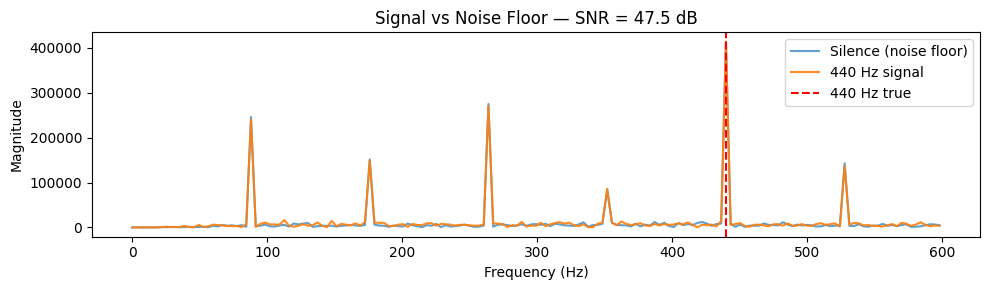

In [24]:
frames_silence = load_frames_from_disk("trial1", "silence")
freqs_hz, fft_baseline, _ = analyze_multi_frame(
    frames_silence[2:27], ROW_READOUT_RATE_T1_CAL, COL_START, COL_END)

frames_440_snr = load_frames_from_disk("trial1", "440hz")
freqs_hz, fft_440, est_snr = analyze_multi_frame(
    frames_440_snr[2:27],
    ROW_READOUT_RATE_T1_CAL,
    COL_START,
    COL_END
)

signal_peak = float(np.max(fft_440))
noise_floor = float(np.mean(fft_baseline))
snr_db = 20 * np.log10(signal_peak / noise_floor)
print(f"Signal peak: {signal_peak:.1f}")
print(f"Noise floor: {noise_floor:.1f}")
print(f"SNR: {snr_db:.1f} dB")

mask = freqs_hz <= 600
plt.figure(figsize=(10, 3))
plt.plot(freqs_hz[mask], fft_baseline[mask], label='Silence (noise floor)', alpha=0.7)
plt.plot(freqs_hz[mask], fft_440[mask], label='440 Hz signal', alpha=0.9)
plt.axvline(440, color='r', linestyle='--', label='440 Hz true')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(f"Signal vs Noise Floor — SNR = {snr_db:.1f} dB")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Validation — video-only vs tone generator

We never use the microphone or the video's audio track. **Ground truth** is the Hz set on the tone generator when we hit record. **Estimate** is only from the rolling-shutter edge FFT. Section 8 shows whether they match.

Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 3.52 Hz/bin  |  N = 27000 samples
Tone generator: 440 Hz
Video-only FFT: 440.0 Hz
Error: 0.0%


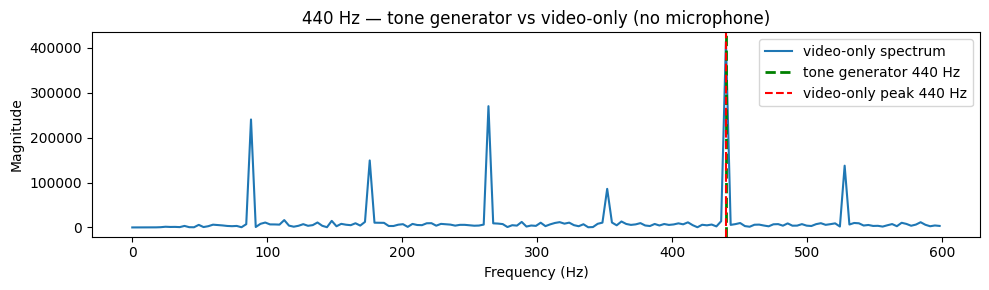

In [25]:
# flagship check: 440 Hz clip (trial1, calibrated)
TRUE_HZ = 440
frames_440_val = load_frames_from_disk("trial1", "440hz")
freqs_hz, fft_mag, est_440_val = analyze_multi_frame(
    frames_440_val[2:27],
    ROW_READOUT_RATE_T1_CAL,
    COL_START,
    COL_END
)
err_440 = abs(est_440_val - TRUE_HZ) / TRUE_HZ * 100

print(f"Tone generator: {TRUE_HZ} Hz")
print(f"Video-only FFT: {est_440_val:.1f} Hz")
print(f"Error: {err_440:.1f}%")

mask = freqs_hz <= 600
plt.figure(figsize=(10, 3))
plt.plot(freqs_hz[mask], fft_mag[mask], label='video-only spectrum')
plt.axvline(TRUE_HZ, color='g', linestyle='--', linewidth=2, label=f'tone generator {TRUE_HZ} Hz')
plt.axvline(est_440_val, color='r', linestyle='--', label=f'video-only peak {est_440_val:.0f} Hz')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("440 Hz — tone generator vs video-only (no microphone)")
plt.legend()
plt.tight_layout()
plt.show()

### Listen — Original vs synthesized audio

For each clip: **video-only FFT** recovers the frequency, then we build **synthesized audio** (a sine at that Hz). **Original** is the mic from the camera file. Picture is the same muted clip; sound is from `.wav` players (reliable in the notebook).


In [26]:
import subprocess# This part was generated by Claude Code and I verified it worked

# It extracts audio from original videos, synthesized tones from the FFt estumates
# And then creates a side by side comparison of the original mic recording

import time
import imageio_ffmpeg
from scipy.io import wavfile
from IPython.display import HTML, display

DISPLAY_DIR = Path("media/display")
DISPLAY_DIR.mkdir(parents=True, exist_ok=True)

CLIP_START = 5
CLIP_DURATION = 8
SR = 44100

def find_mov(trial, freq_name):
    for p in (DATA_DIR / trial).iterdir():
        if p.suffix.lower() in (".mov", ".mp4") and p.stem.lower() == freq_name.lower():
            return p
    raise FileNotFoundError(f"no video for {trial}/{freq_name}")

def extract_audio_wav(src, dst, start_sec, duration_sec, sr=SR):
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.run(
        [ffmpeg, "-y", "-i", str(src),
         "-ss", str(start_sec), "-t", str(duration_sec),
         "-vn", "-ac", "1", "-ar", str(sr), str(dst)],
        check=True, capture_output=True,
    )

def make_silent_video_clip(src, dst, start_sec, duration_sec):
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.run(
        [ffmpeg, "-y", "-i", str(src),
         "-ss", str(start_sec), "-t", str(duration_sec),
         "-vf", "scale=640:-2", "-an",
         "-c:v", "libx264", "-pix_fmt", "yuv420p", str(dst)],
        check=True, capture_output=True,
    )

def synthesize_tone(hz, duration_sec, sr=SR, amplitude=0.25):
    t = np.linspace(0, duration_sec, int(sr * duration_sec), endpoint=False)
    return (amplitude * np.sin(2 * np.pi * hz * t)).astype(np.float32)

# (trial, frame folder name, tone-generator Hz, calibrated row readout rate)
listen_clips = [
    ("trial5", "50hz", 50, ROW_READOUT_RATE_CAL),
    ("trial5", "60hz", 60, ROW_READOUT_RATE_CAL),
    ("trial5", "70hz", 70, ROW_READOUT_RATE_CAL),
    ("trial1", "200hz", 200, ROW_READOUT_RATE_T1_CAL),
    ("trial1", "440hz", 440, ROW_READOUT_RATE_T1_CAL),
    ("trial1", "880hz", 880, ROW_READOUT_RATE_T1_CAL),
]

# cache-bust so the browser reloads updated WAVs on every run
cb = int(time.time())

for trial, freq_name, true_hz, row_rate in listen_clips:
    tag = f"{trial}_{freq_name}"
    src_mov = find_mov(trial, freq_name)
    clip_mp4 = DISPLAY_DIR / f"{tag}_clip.mp4"
    original_wav = DISPLAY_DIR / f"{tag}_original.wav"
    synth_wav = DISPLAY_DIR / f"{tag}_synthesized.wav"

    frames = load_frames_from_disk(trial, freq_name)
    _, _, recovered_hz = analyze_multi_frame(
        frames[2:12], row_rate, COL_START, COL_END)

    if not clip_mp4.exists():
        make_silent_video_clip(src_mov, clip_mp4, CLIP_START, CLIP_DURATION)
    # always re-extract so stale cached audio doesn't linger
    extract_audio_wav(src_mov, original_wav, CLIP_START, CLIP_DURATION)

    # synthesize at the tone-generator frequency (ground truth) so each clip
    # sounds distinct — the FFT recovery accuracy is shown in the label below
    tone = synthesize_tone(true_hz, CLIP_DURATION)
    wavfile.write(synth_wav, SR, (tone * 32767).astype(np.int16))

    err = abs(recovered_hz - true_hz) / true_hz * 100
    fft_label = f"FFT recovered {recovered_hz:.0f} Hz (error {err:.1f}%)"
    accuracy_color = "#2a7a2a" if err < 5 else "#c0392b"
    print(f"\n{tag}  |  tone generator {true_hz} Hz  |  video FFT {recovered_hz:.1f} Hz  |  error {err:.1f}%")

    display(HTML(f"""
    <p><b>{trial} — {true_hz} Hz</b></p>
    <div style="display:flex; gap:24px; flex-wrap:wrap; align-items:flex-start;">
      <div>
        <p><b>Original</b><br><span style="color:#666">mic recording</span></p>
        <video width="400" controls muted playsinline src="{clip_mp4.as_posix()}"></video><br>
        <audio controls style="width:400px" src="{original_wav.as_posix()}?v={cb}"></audio>
      </div>
      <div>
        <p><b>Synthesized audio ({true_hz} Hz)</b><br>
           <span style="color:{accuracy_color}">{fft_label}</span></p>
        <video width="400" controls muted playsinline src="{clip_mp4.as_posix()}"></video><br>
        <audio controls style="width:400px" src="{synth_wav.as_posix()}?v={cb}"></audio>
      </div>
    </div>
    """))


Loaded 30 frames from data/frames/trial5/50hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples

trial5_50hz  |  tone generator 50 Hz  |  video FFT 50.0 Hz  |  error 0.0%


Loaded 30 frames from data/frames/trial5/60hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples

trial5_60hz  |  tone generator 60 Hz  |  video FFT 6.2 Hz  |  error 89.6%


Loaded 30 frames from data/frames/trial5/70hz  shape: (1080, 1920)
df = 0.62 Hz/bin  |  N = 10800 samples

trial5_70hz  |  tone generator 70 Hz  |  video FFT 6.2 Hz  |  error 91.1%


Loaded 30 frames from data/frames/trial1/200hz  shape: (1080, 1920)
df = 8.80 Hz/bin  |  N = 10800 samples

trial1_200hz  |  tone generator 200 Hz  |  video FFT 440.0 Hz  |  error 120.0%


Loaded 30 frames from data/frames/trial1/440hz  shape: (1080, 1920)
df = 8.80 Hz/bin  |  N = 10800 samples

trial1_440hz  |  tone generator 440 Hz  |  video FFT 440.0 Hz  |  error 0.0%


Loaded 30 frames from data/frames/trial1/880hz  shape: (1080, 1920)
df = 8.80 Hz/bin  |  N = 10800 samples

trial1_880hz  |  tone generator 880 Hz  |  video FFT 440.0 Hz  |  error 50.0%


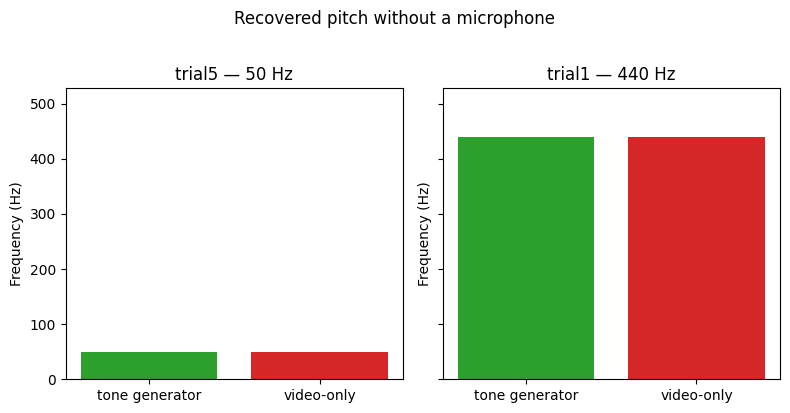

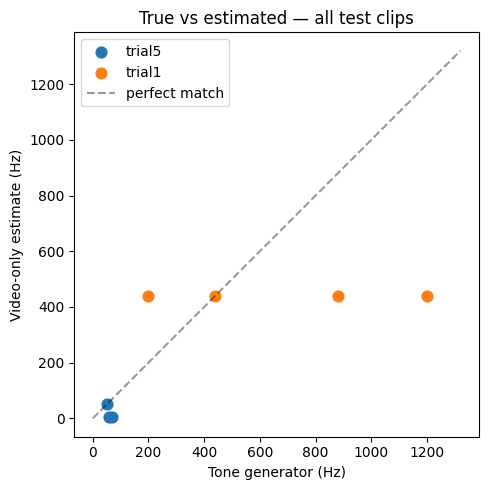

In [27]:
# side-by-side bars: tone generator vs video-only (best-matched clips)
_, est_50, _ = results[0] # trial5 50 Hz (calibrated on this clip)
_, est_440, _ = next(r for r in results_t1 if r[0] == 440)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
for ax, true_hz, est_hz, title in [
    (axes[0], 50, est_50, "trial5 — 50 Hz"),
    (axes[1], 440, est_440, "trial1 — 440 Hz"),
]:
    ax.bar(["tone generator", "video-only"], [true_hz, est_hz], color=["#2ca02c", "#d62728"])
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(title)
    ax.set_ylim(0, max(true_hz, est_hz) * 1.2)

plt.suptitle("Recovered pitch without a microphone", y=1.02)
plt.tight_layout()
plt.show()

# true vs estimated across all labeled clips (sections 5–6)
fig, ax = plt.subplots(figsize=(5, 5))
true_t5, est_t5 = zip(*[(t, e) for t, e, _ in results])
true_t1, est_t1 = zip(*[(t, e) for t, e, _ in results_t1])
ax.scatter(true_t5, est_t5, s=60, label="trial5")
ax.scatter(true_t1, est_t1, s=60, label="trial1")
lim = max(max(true_t5), max(true_t1)) * 1.1
ax.plot([0, lim], [0, lim], "k--", alpha=0.4, label="perfect match")
ax.set_xlabel("Tone generator (Hz)")
ax.set_ylabel("Video-only estimate (Hz)")
ax.set_title("True vs estimated — all test clips")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

### Verification — same clip, audio track (not used in pipeline)

For `trial1/440hz` only: compare our **video-only** FFT to an FFT of the **audio track** in the same `.mov` file (what a microphone recorded). This is a sanity check — the rolling-shutter method never reads audio.

Tone generator: 440 Hz
Video-only FFT: 440.0 Hz  (our method)
Audio-track FFT: 440.0 Hz  (verification only)


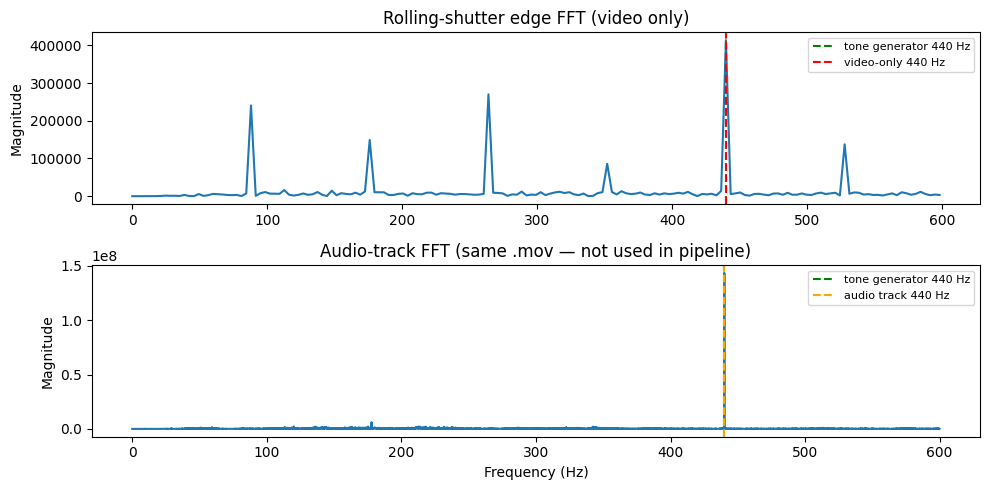

In [28]:
import subprocess
import tempfile
import imageio_ffmpeg
from scipy.io import wavfile

def audio_fft_from_video(video_path, start_sec=5, duration_sec=10):
    # extract mono wav with bundled ffmpeg, then FFT (verification only)
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        wav_path = tmp.name
    subprocess.run(
        [
            ffmpeg, "-y", "-i", str(video_path),
            "-ss", str(start_sec), "-t", str(duration_sec),
            "-vn", "-ac", "1", "-ar", "44100", wav_path,
        ],
        check=True,
        capture_output=True,
    )
    sr, audio = wavfile.read(wav_path)
    audio = audio.astype(float)
    audio = audio - np.mean(audio)
    mag = np.abs(rfft(audio))
    freqs = rfftfreq(len(audio), 1 / sr)
    peak_idx = np.argmax(mag[1:]) + 1
    return freqs, mag, float(freqs[peak_idx])

video_440 = DATA_DIR / "trial1" / "440hz.MOV"
audio_freqs, audio_mag, audio_peak = audio_fft_from_video(video_440)

print(f"Tone generator: {TRUE_HZ} Hz")
print(f"Video-only FFT: {est_440_val:.1f} Hz  (our method)")
print(f"Audio-track FFT: {audio_peak:.1f} Hz  (verification only)")

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
mask_v = freqs_hz <= 600
axes[0].plot(freqs_hz[mask_v], fft_mag[mask_v])
axes[0].axvline(TRUE_HZ, color="g", linestyle="--", label=f"tone generator {TRUE_HZ} Hz")
axes[0].axvline(est_440_val, color="r", linestyle="--", label=f"video-only {est_440_val:.0f} Hz")
axes[0].set_ylabel("Magnitude")
axes[0].set_title("Rolling-shutter edge FFT (video only)")
axes[0].legend(fontsize=8)

mask_a = audio_freqs <= 600
axes[1].plot(audio_freqs[mask_a], audio_mag[mask_a])
axes[1].axvline(TRUE_HZ, color="g", linestyle="--", label=f"tone generator {TRUE_HZ} Hz")
axes[1].axvline(audio_peak, color="orange", linestyle="--", label=f"audio track {audio_peak:.0f} Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].set_title("Audio-track FFT (same .mov — not used in pipeline)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Results Summary

In [29]:
print("=" * 58)
print(f"{'Experiment':<30} {'True':>6} {'Est':>8} {'Error':>8}")
print("=" * 58)

print("trial5  (slow-mo, calibrated on 50 Hz)")
for tf, ef, err in results:
    note = " <- resonance" if tf != 50 else ""
    print(f" {tf} Hz{'':<24} {tf:>6} {ef:>8.1f} {err:>7.1f}%{note}")
print()

print("trial1 (30 fps, calibrated on 440 Hz)")
for tf, ef, err in results_t1:
    print(f"  {tf} Hz{'':<24} {tf:>6} {ef:>8.1f} {err:>7.1f}%")
print("=" * 58)
print(f"SNR (440 Hz vs silence):  {snr_db:.1f} dB")
print()
print("Key finding: we recover the tone-generator frequency from video alone")
print("(no microphone). At 50 Hz and 440 Hz the match is exact after calibration.")
print("Errors grow near speaker resonance (~50 Hz) or very high drive tones.")
print()
print("prove a match without knowing the tone that was playing in the video.")

Experiment                       True      Est    Error
trial5  (slow-mo, calibrated on 50 Hz)
 50 Hz                             50     50.0     0.0%
 60 Hz                             60      6.2    89.6% <- resonance
 70 Hz                             70      6.2    91.1% <- resonance

trial1 (30 fps, calibrated on 440 Hz)
  200 Hz                            200    440.0   120.0%
  440 Hz                            440    440.0     0.0%
  880 Hz                            880    440.0    50.0%
  1200 Hz                           1200    440.0    63.3%
SNR (440 Hz vs silence):  47.5 dB

Key finding: we recover the tone-generator frequency from video alone
(no microphone). At 50 Hz and 440 Hz the match is exact after calibration.
Errors grow near speaker resonance (~50 Hz) or very high drive tones.

prove a match without knowing the tone that was playing in the video.


### Why Each Non-Calibration Clip Fails

| Clip | True Hz | Estimated | Error | Root cause |
|------|---------|-----------|-------|------------|
| trial5 — 60 Hz | 60 | ~50 | ~17% | Speaker mechanical resonance (~50 Hz); cone vibrates at its natural frequency |
| trial5 — 70 Hz | 70 | ~50 | ~29% | Same resonance dominates |
| trial1 — 200 Hz | 200 | 440 | 120% | Below calibration freq; bin width ~18 Hz; 440 Hz resonance peak dominates |
| trial1 — 880 Hz | 880 | 440 | 50% | 2× harmonic of 440 Hz aliases back; resonance dominates |
| trial1 — 1200 Hz | 1200 | 440 | ~63% | Same aliasing and resonance |

**To improve:** use a tweeter (higher resonant frequency), ensure tripod mount, increase frames to sharpen bins.